# Learning Curve: SERP Expertise Over 60 Trials

Participants completed ~60 trials each (6 blocks × 10 trials). The learning curve across trials is itself a finding: we're watching SERP expertise form in real time — from naive layout discovery to automatic motor routines. The asymptotic pattern is what power users do in production; the early-trial pattern is what first-time visitors do.

**Attention construct:** This notebook measures *practiced efficiency* — how overt scanning, motor control, and cognitive load change with experience on a fixed task structure.

**Metrics by trial ordinal:**
1. Orientation time (page load → first result fixation)
2. Trial duration
3. Survey amplitude (max saccade Y extent in first pass)
4. Regression rate (% trials with backward scroll)
5. Click position
6. Fixation count
7. LHIPA (cognitive load)

In [1]:
from data_loader import *
setup_plotting()
import os, re, json
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── Parse trial ordinal from trial ID ────────────────────────────────
# p004-b1-t1 → participant='p004', block=1, trial=1, ordinal=1
# p004-b2-t3 → ordinal=13

def parse_trial_id(tid):
    """Extract participant, block, trial, and ordinal from trial ID."""
    m = re.match(r'(p\d+)-b(\d+)-t(\d+)', tid)
    if not m:
        return None
    pid, block, trial = m.group(1), int(m.group(2)), int(m.group(3))
    ordinal = (block - 1) * 10 + trial
    return {'pid': pid, 'block': block, 'trial': trial, 'ordinal': ordinal}

# Verify: check ordinal range
trial_ids = get_trial_ids()
ordinals = [parse_trial_id(t)['ordinal'] for t in trial_ids if parse_trial_id(t)]
print(f'{len(trial_ids)} trials, ordinal range {min(ordinals)}–{max(ordinals)}')
print(f'{len(set(parse_trial_id(t)["pid"] for t in trial_ids if parse_trial_id(t)))} participants')

2776 trials, ordinal range 1–60
47 participants


In [2]:
# ── Compute per-trial metrics ─────────────────────────────────────────

lhipa_data = load_lhipa()

records = []
skipped = 0

for tid in trial_ids:
    info = parse_trial_id(tid)
    if not info:
        skipped += 1
        continue

    trial = load_trial(tid)
    if trial is None:
        skipped += 1
        continue

    fixations = trial['fixations']
    scrolls = trial['scrolls']
    clicks = trial['clicks']
    doc_h = trial['doc_height']
    n_results = count_results_html(tid)
    if n_results == 0:
        n_results = 11  # fallback

    tops = result_band_tops(n_results, doc_h)
    scroll_ts = trial['scroll_ts']
    scroll_ys = trial['scroll_ys']

    # 1. Orientation time: first fixation → first fixation on a result
    orientation_ms = None
    if fixations:
        t0 = fixations[0]['t']
        for fix in fixations:
            sy = interpolate_scroll(fix['t'], scroll_ts, scroll_ys)
            pos = assign_fixation_to_position(fix['y'], sy, tops, n_results)
            if pos >= 0:
                orientation_ms = fix['t'] - t0
                break

    # 2. Trial duration
    duration_ms = None
    if fixations:
        duration_ms = fixations[-1]['t'] - fixations[0]['t']

    # 3. Survey amplitude: max page-space Y reached before first regression
    #    (first backward scroll or backward saccade > 200px)
    max_page_y = 0
    if fixations:
        for fix in fixations:
            sy = interpolate_scroll(fix['t'], scroll_ts, scroll_ys)
            page_y = fix['y'] + sy
            if page_y < max_page_y - 200:
                break  # regression detected
            max_page_y = max(max_page_y, page_y)

    # 4. Regression: did backward scroll happen?
    has_regression = False
    if len(scroll_ys) >= 2:
        for i in range(1, len(scroll_ys)):
            if scroll_ys[i] < scroll_ys[i - 1] - 50:
                has_regression = True
                break

    # 5. Click position
    # Coordinate-safe: assign_fixation_to_position expects screen-space.
    # cy is already page-space, so bisect directly against page-space tops.
    click_pos = None
    if clicks:
        _ct, _cx, cy = clicks[-1]
        pos_raw = bisect_right(tops, cy) - 1
        if 0 <= pos_raw < n_results:
            click_pos = pos_raw

    # 6. Fixation count
    n_fixations = len(fixations)

    # 7. LHIPA
    lhipa_val = None
    if tid in lhipa_data:
        lhipa_val = lhipa_data[tid].get('lhipa')

    records.append({
        'tid': tid,
        'pid': info['pid'],
        'ordinal': info['ordinal'],
        'block': info['block'],
        'orientation_ms': orientation_ms,
        'duration_ms': duration_ms,
        'survey_amplitude': max_page_y,
        'has_regression': has_regression,
        'click_pos': click_pos,
        'n_fixations': n_fixations,
        'lhipa': lhipa_val,
    })

print(f'Computed metrics for {len(records)} trials (skipped {skipped})')
print(f'  orientation: {sum(1 for r in records if r["orientation_ms"] is not None)} trials')
print(f'  LHIPA: {sum(1 for r in records if r["lhipa"] is not None)} trials')
print(f'  click position: {sum(1 for r in records if r["click_pos"] is not None and r["click_pos"] >= 0)} trials')

Computed metrics for 2776 trials (skipped 0)
  orientation: 2774 trials
  LHIPA: 2721 trials
  click position: 2764 trials


In [3]:
# ── Helper: aggregate by ordinal with participant-level means ─────────
# For each ordinal, compute participant means first, then grand mean + SEM.
# This respects the repeated-measures structure (each participant contributes
# one value per ordinal, not one value per trial).

def by_ordinal(records, metric, filter_fn=None):
    """Group metric by trial ordinal, return ordinals, means, SEMs.
    
    filter_fn: optional predicate on record dict.
    Returns only ordinals with ≥5 participants.
    """
    # Collect per-participant-per-ordinal values
    pid_ord = defaultdict(list)  # (pid, ordinal) → [values]
    for r in records:
        val = r[metric]
        if val is None:
            continue
        if filter_fn and not filter_fn(r):
            continue
        pid_ord[(r['pid'], r['ordinal'])].append(val)
    
    # Average within participant-ordinal, then across participants per ordinal
    ord_vals = defaultdict(list)  # ordinal → [participant means]
    for (pid, ordinal), vals in pid_ord.items():
        ord_vals[ordinal].append(np.mean(vals))
    
    ordinals = sorted(ord_vals.keys())
    means, sems = [], []
    valid_ords = []
    for o in ordinals:
        v = ord_vals[o]
        if len(v) >= 5:
            valid_ords.append(o)
            means.append(np.mean(v))
            sems.append(np.std(v, ddof=1) / np.sqrt(len(v)))
    
    return np.array(valid_ords), np.array(means), np.array(sems)

def by_ordinal_rate(records, bool_metric):
    """Like by_ordinal but for boolean metrics — returns proportion."""
    pid_ord = defaultdict(list)
    for r in records:
        val = r[bool_metric]
        if val is None:
            continue
        pid_ord[(r['pid'], r['ordinal'])].append(float(val))
    
    ord_vals = defaultdict(list)
    for (pid, ordinal), vals in pid_ord.items():
        ord_vals[ordinal].append(np.mean(vals))
    
    ordinals = sorted(ord_vals.keys())
    means, sems = [], []
    valid_ords = []
    for o in ordinals:
        v = ord_vals[o]
        if len(v) >= 5:
            valid_ords.append(o)
            means.append(np.mean(v))
            sems.append(np.std(v, ddof=1) / np.sqrt(len(v)))
    
    return np.array(valid_ords), np.array(means), np.array(sems)

print('Aggregation helpers ready.')

Aggregation helpers ready.


## Overview: All Metrics by Trial Ordinal

Each point is the grand mean across participants for that trial ordinal (1–60). Error bands are ±1 SEM computed across participant means. Block boundaries shown as vertical lines — if learning resets at block transitions, these will show discontinuities.

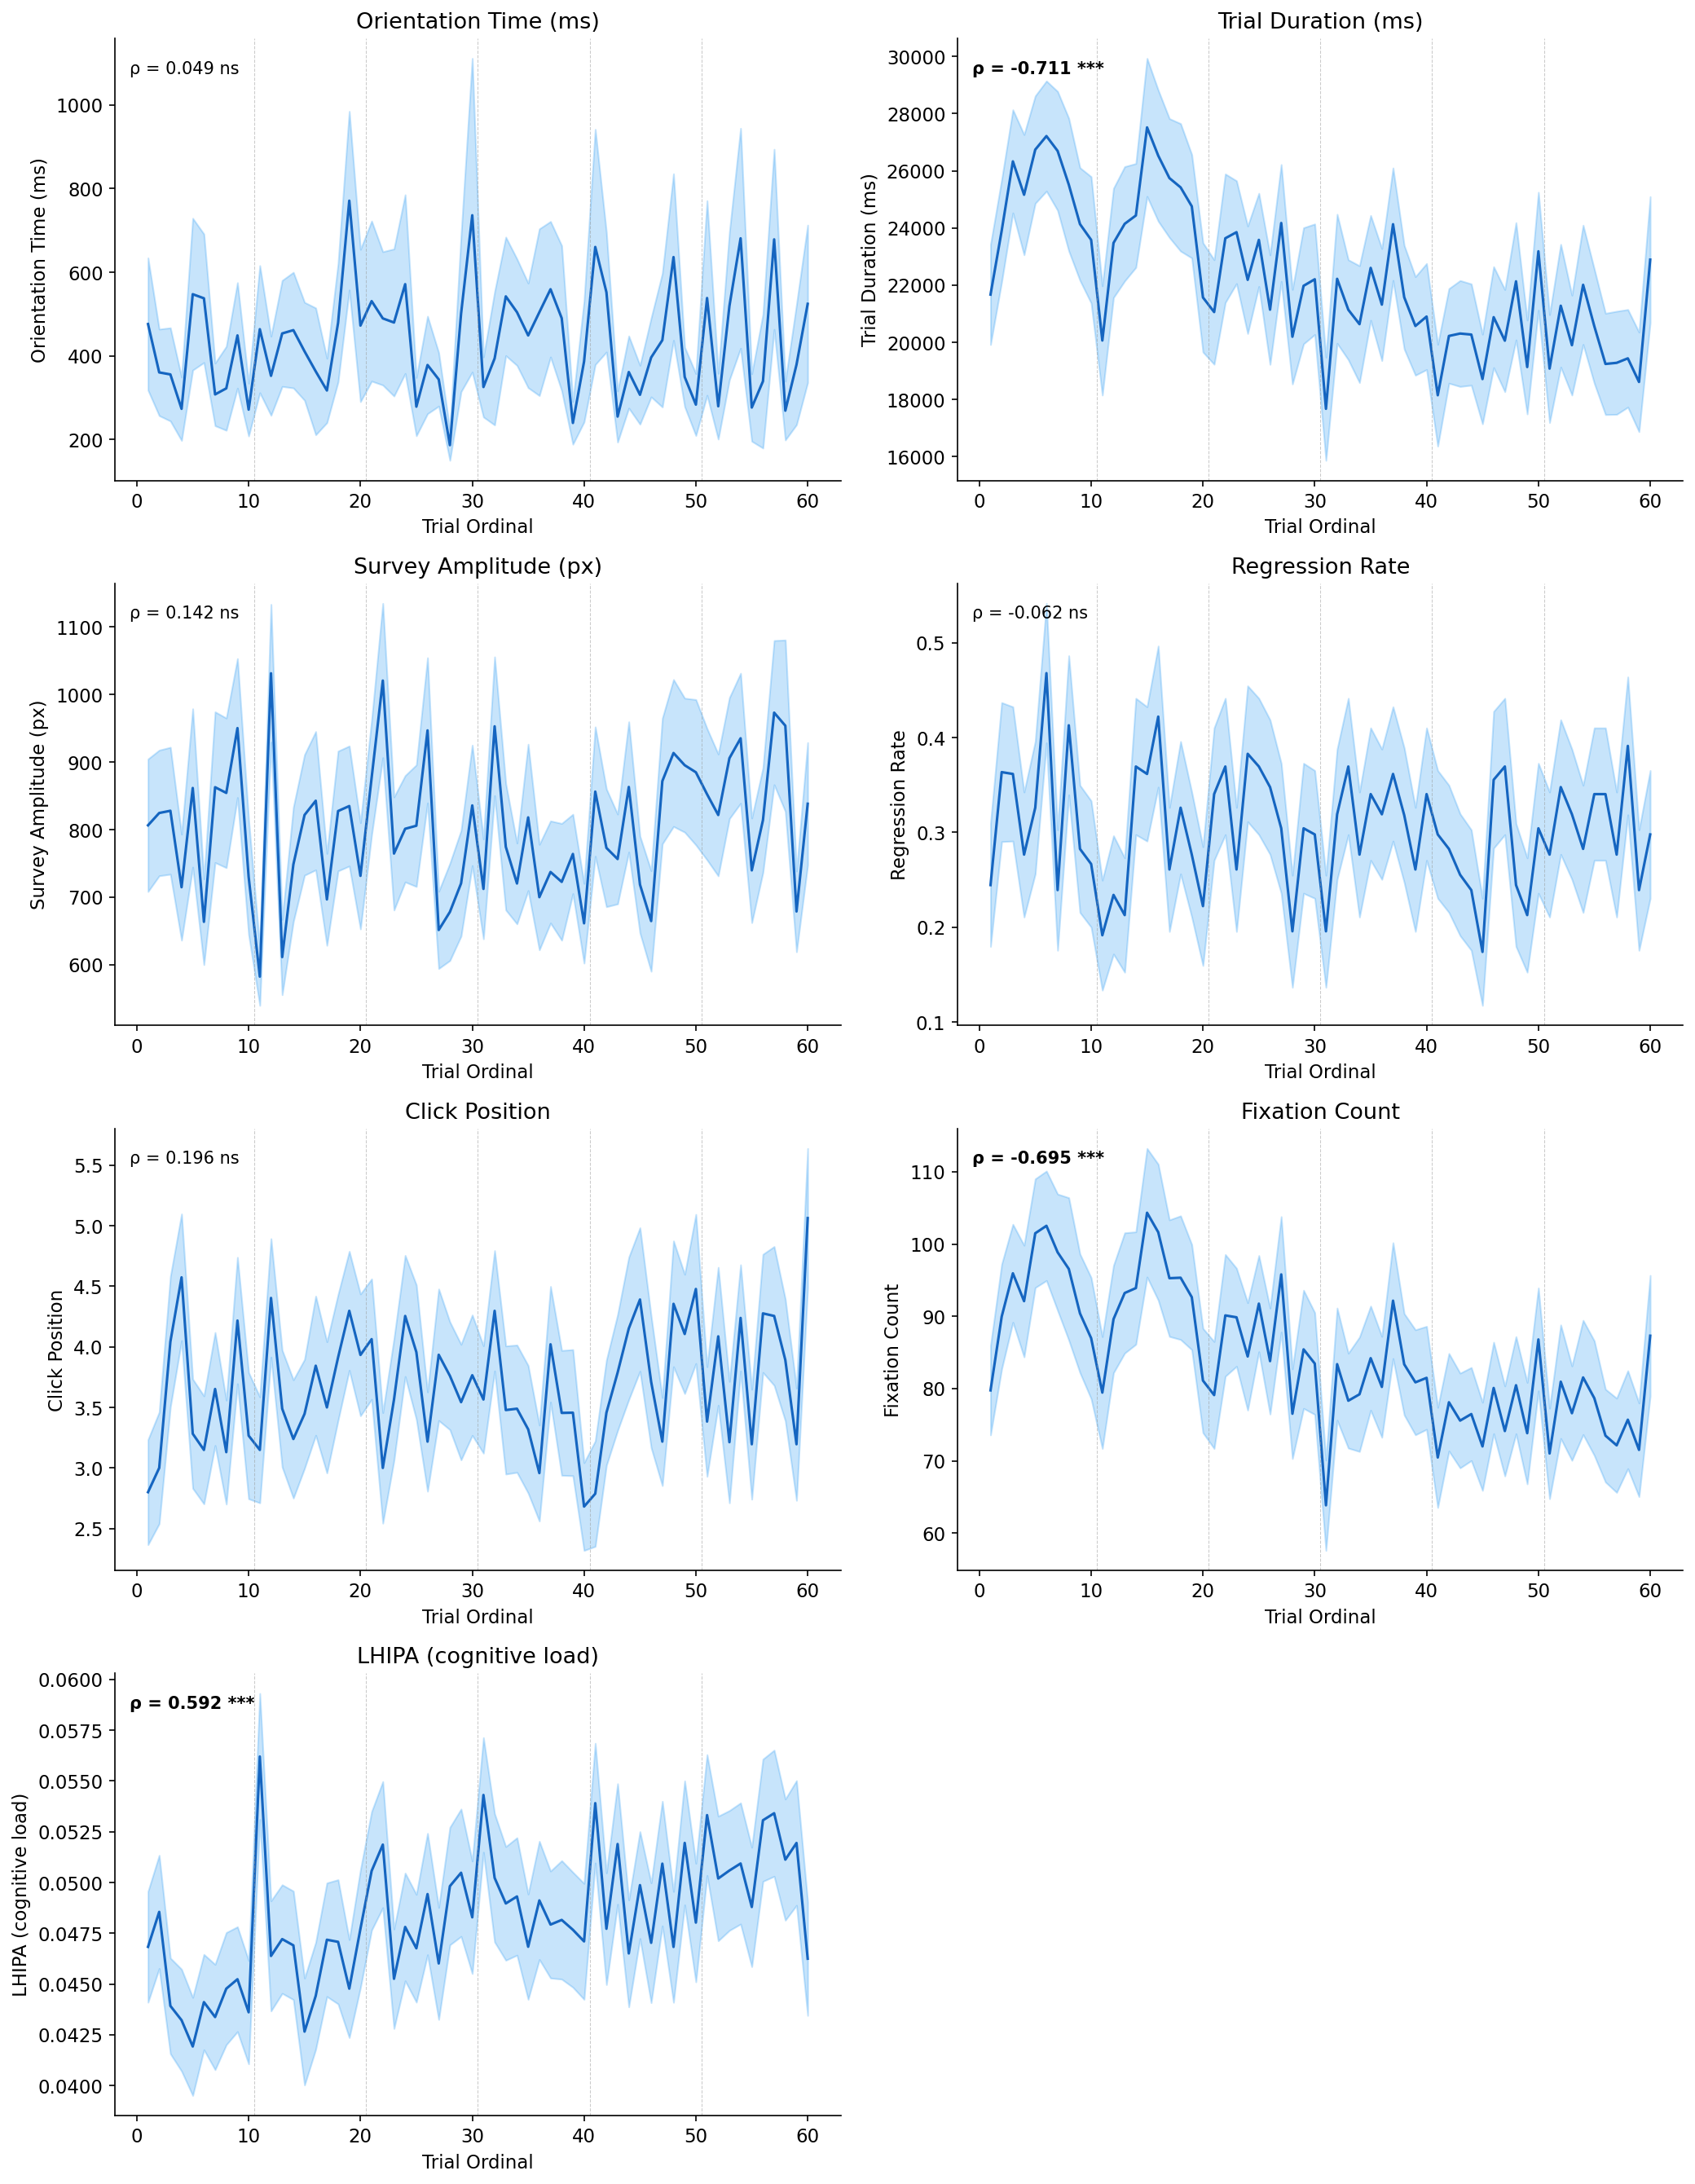

Saved 18_learning_overview.png


In [4]:
# ── 7-panel learning curve overview ───────────────────────────────────

metrics = [
    ('orientation_ms', 'Orientation Time (ms)', False),
    ('duration_ms', 'Trial Duration (ms)', False),
    ('survey_amplitude', 'Survey Amplitude (px)', False),
    ('has_regression', 'Regression Rate', True),
    ('click_pos', 'Click Position', False),
    ('n_fixations', 'Fixation Count', False),
    ('lhipa', 'LHIPA (cognitive load)', False),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, (metric, label, is_bool) in enumerate(metrics):
    ax = axes[i]
    
    if is_bool:
        ords, means, sems = by_ordinal_rate(records, metric)
    else:
        ords, means, sems = by_ordinal(records, metric)
    
    ax.fill_between(ords, means - sems, means + sems, alpha=0.25, color='#2196F3')
    ax.plot(ords, means, color='#1565C0', linewidth=1.5)
    
    # Block boundaries
    for b in [10.5, 20.5, 30.5, 40.5, 50.5]:
        ax.axvline(b, color='#999', linewidth=0.5, linestyle='--', alpha=0.5)
    
    ax.set_xlabel('Trial Ordinal')
    ax.set_ylabel(label)
    ax.set_title(label)
    
    # Spearman correlation with ordinal
    valid = [(o, m) for o, m in zip(ords, means) if np.isfinite(m)]
    if len(valid) >= 5:
        vo, vm = zip(*valid)
        rho, p = stats.spearmanr(vo, vm)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        ax.text(0.02, 0.95, f'ρ = {rho:.3f} {sig}',
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                fontweight='bold' if p < 0.05 else 'normal')

# Hide unused panel
axes[7].set_visible(False)

plt.tight_layout()
plt.savefig('18_learning_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved 18_learning_overview.png')

## Early vs. Late: Trials 1–10 vs. 51–60

Direct comparison of first and last blocks. If SERP expertise forms, the late block should show faster orientation, shorter trials, fewer fixations, and higher LHIPA (less load). Wilcoxon signed-rank tests paired by participant.

In [5]:
# ── Early (1–10) vs Late (51–60) paired comparison ───────────────────

early = [r for r in records if r['ordinal'] <= 10]
late  = [r for r in records if r['ordinal'] >= 51]

def participant_means(recs, metric):
    """Compute per-participant mean for a metric."""
    pid_vals = defaultdict(list)
    for r in recs:
        val = r[metric]
        if val is None:
            continue
        if isinstance(val, bool):
            val = float(val)
        pid_vals[r['pid']].append(val)
    return {pid: np.mean(vals) for pid, vals in pid_vals.items()}

test_metrics = [
    ('orientation_ms', 'Orientation (ms)'),
    ('duration_ms', 'Duration (ms)'),
    ('n_fixations', 'Fixations'),
    ('has_regression', 'Regression rate'),
    ('click_pos', 'Click position'),
    ('lhipa', 'LHIPA'),
    ('survey_amplitude', 'Survey amplitude (px)'),
]

print(f'{"Metric":<22} {"Early":>8} {"Late":>8} {"Δ":>8} {"Δ%":>7}  {"W":>8} {"p":>10}')
print('─' * 78)

for metric, label in test_metrics:
    e_means = participant_means(early, metric)
    l_means = participant_means(late, metric)
    
    # Paired: only participants in both
    shared_pids = sorted(set(e_means) & set(l_means))
    if len(shared_pids) < 5:
        print(f'{label:<22} insufficient paired data ({len(shared_pids)} participants)')
        continue
    
    e_arr = np.array([e_means[p] for p in shared_pids])
    l_arr = np.array([l_means[p] for p in shared_pids])
    
    e_grand = np.mean(e_arr)
    l_grand = np.mean(l_arr)
    delta = l_grand - e_grand
    pct = 100 * delta / e_grand if e_grand != 0 else 0
    
    w_stat, w_p = stats.wilcoxon(e_arr, l_arr)
    sig = '***' if w_p < 0.001 else '**' if w_p < 0.01 else '*' if w_p < 0.05 else ''
    
    print(f'{label:<22} {e_grand:>8.1f} {l_grand:>8.1f} {delta:>+8.1f} {pct:>+6.1f}%  {w_stat:>8.0f} {w_p:>10.4f} {sig}')

print(f'\nn = {len(shared_pids)} participants with data in both blocks 1 and 6')

Metric                    Early     Late        Δ      Δ%         W          p
──────────────────────────────────────────────────────────────────────────────
Orientation (ms)          402.2    449.6    +47.4  +11.8%       516     0.6078 
Duration (ms)           25405.5  20289.3  -5116.2  -20.1%       187     0.0000 ***
Fixations                  94.4     77.0    -17.4  -18.5%       242     0.0004 ***
Regression rate             0.3      0.3     -0.0   -5.4%       316     0.5920 
Click position              3.5      3.9     +0.4  +10.7%       356     0.1559 
LHIPA                       0.0      0.1     +0.0  +14.7%       152     0.0000 ***
Survey amplitude (px)     810.8    850.3    +39.6   +4.9%       491     0.4465 

n = 47 participants with data in both blocks 1 and 6


## Block-Level Means

Collapse within blocks to see if learning is continuous or shows block-transition effects (reset, fatigue, warm-up).

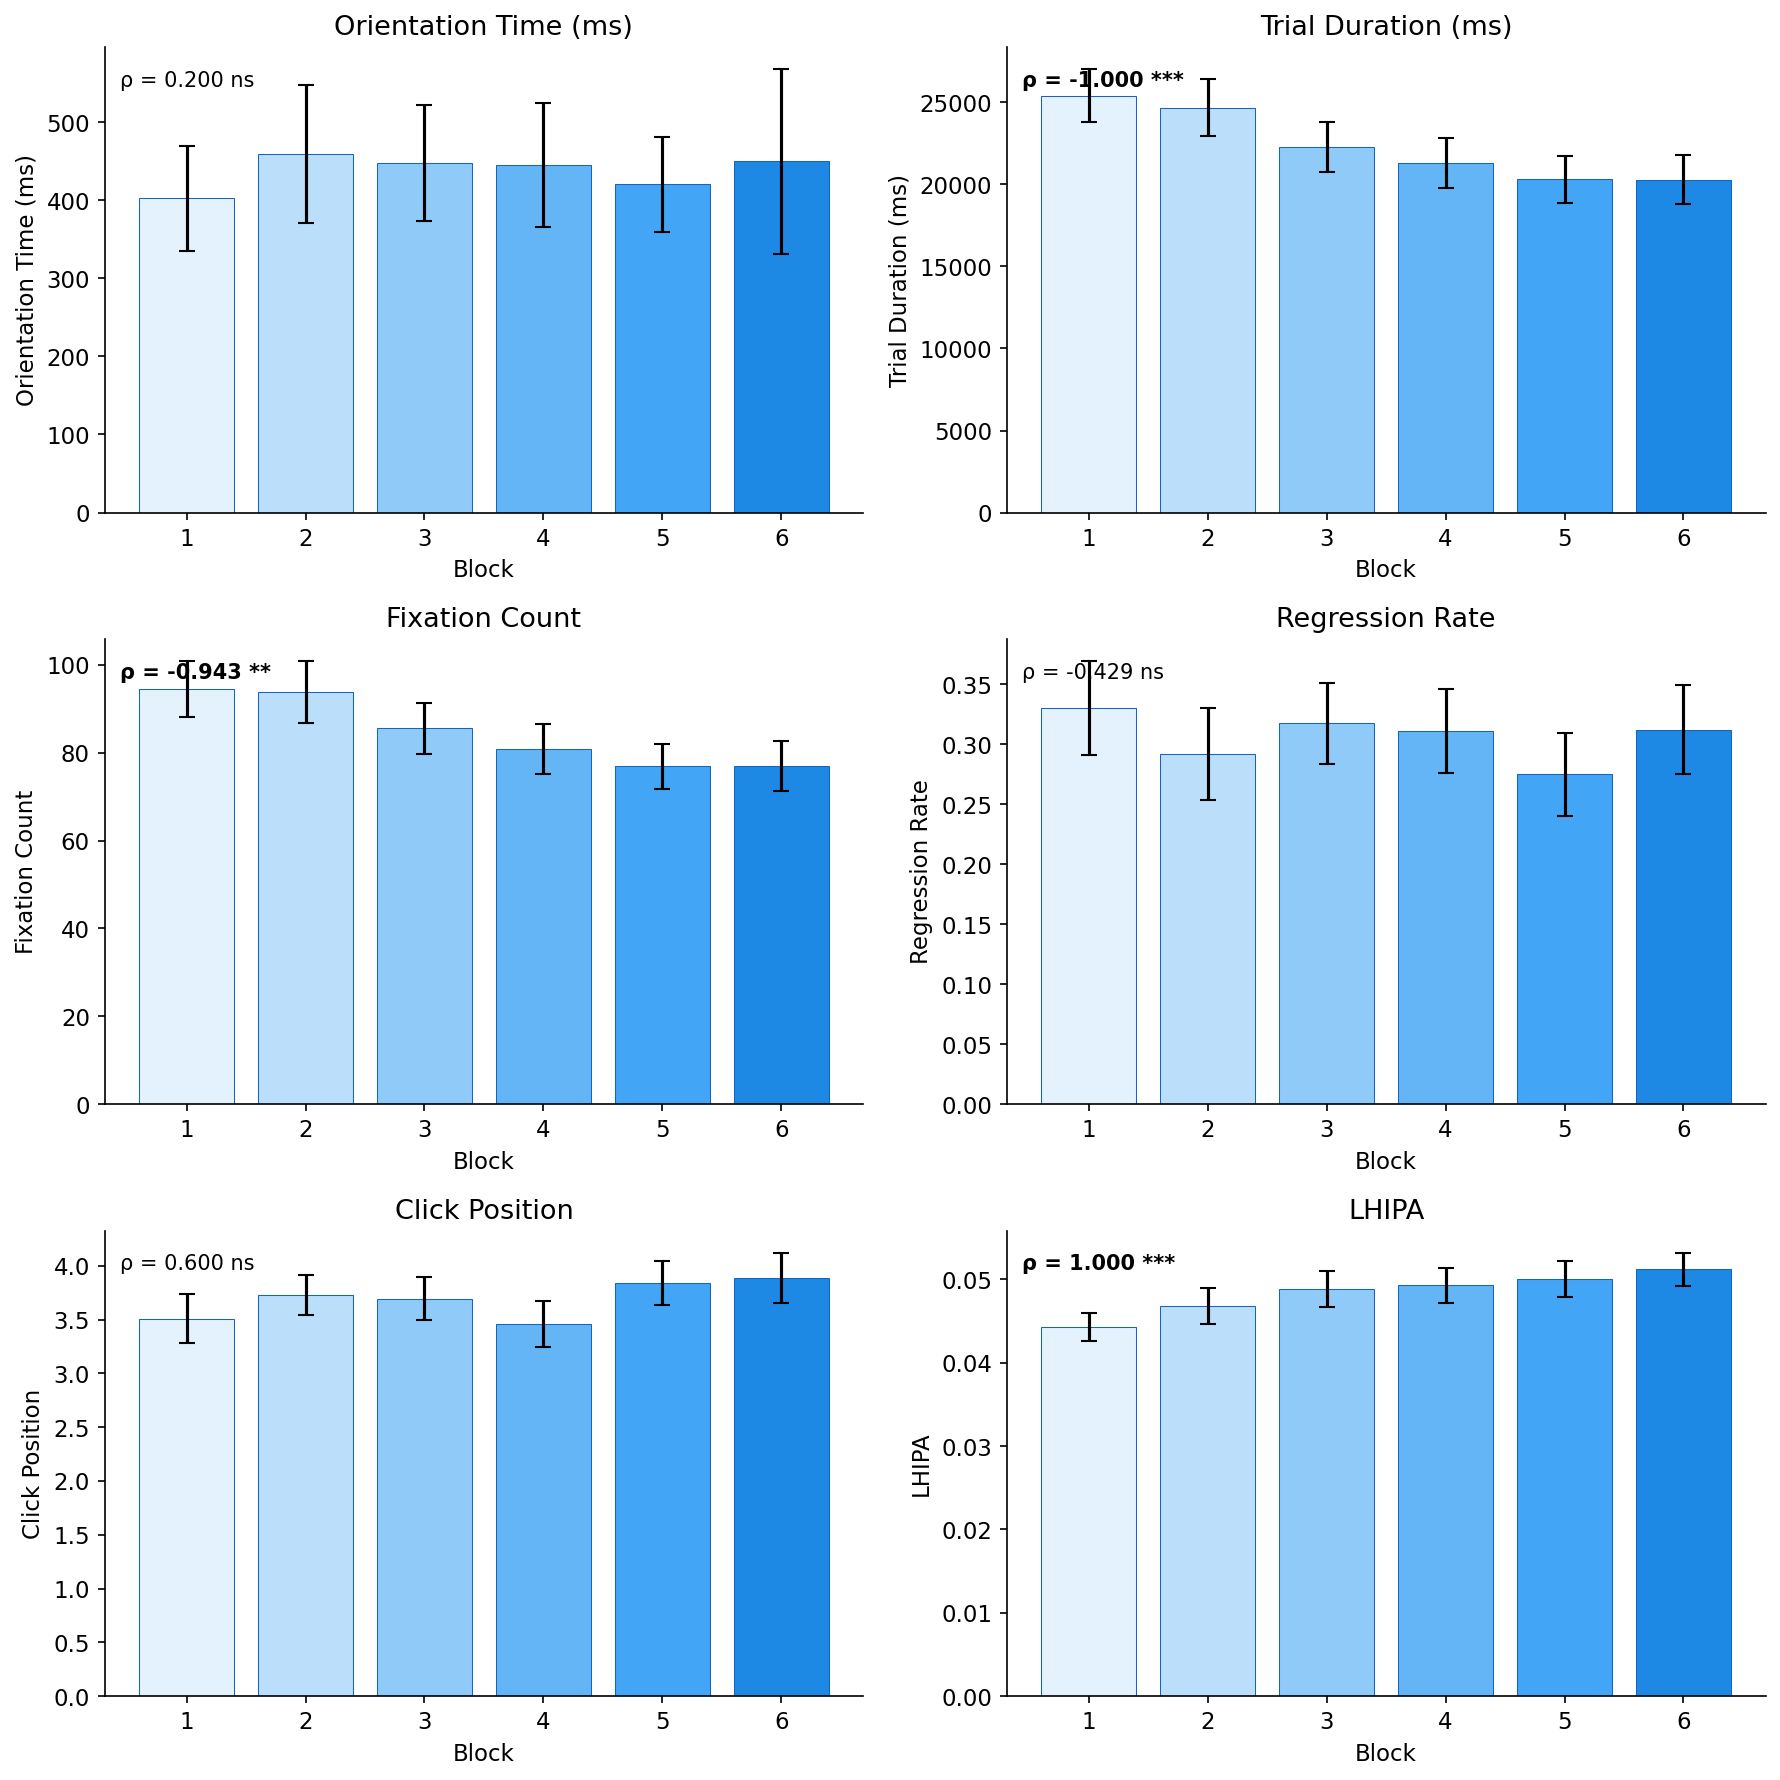

Saved 18_learning_blocks.png


In [6]:
# ── Block-level bar chart ─────────────────────────────────────────────

plot_metrics = [
    ('orientation_ms', 'Orientation Time (ms)', False),
    ('duration_ms', 'Trial Duration (ms)', False),
    ('n_fixations', 'Fixation Count', False),
    ('has_regression', 'Regression Rate', True),
    ('click_pos', 'Click Position', False),
    ('lhipa', 'LHIPA', False),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

blocks = [1, 2, 3, 4, 5, 6]

for i, (metric, label, is_bool) in enumerate(plot_metrics):
    ax = axes[i]
    block_means = []
    block_sems = []
    
    for b in blocks:
        block_recs = [r for r in records if r['block'] == b]
        pid_vals = defaultdict(list)
        for r in block_recs:
            val = r[metric]
            if val is None:
                continue
            if isinstance(val, bool):
                val = float(val)
            pid_vals[r['pid']].append(val)
        
        pmeans = [np.mean(v) for v in pid_vals.values() if len(v) > 0]
        if pmeans:
            block_means.append(np.mean(pmeans))
            block_sems.append(np.std(pmeans, ddof=1) / np.sqrt(len(pmeans)))
        else:
            block_means.append(0)
            block_sems.append(0)
    
    colors = ['#E3F2FD', '#BBDEFB', '#90CAF9', '#64B5F6', '#42A5F5', '#1E88E5']
    bars = ax.bar(blocks, block_means, yerr=block_sems, capsize=4,
                  color=colors, edgecolor='#1565C0', linewidth=0.5)
    ax.set_xlabel('Block')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_xticks(blocks)
    
    # Trend test: Page's L (monotonic trend across blocks)
    rho, p = stats.spearmanr(blocks, block_means)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.text(0.02, 0.95, f'ρ = {rho:.3f} {sig}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            fontweight='bold' if p < 0.05 else 'normal')

plt.tight_layout()
plt.savefig('18_learning_blocks.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved 18_learning_blocks.png')

## Power Law of Practice

Skill acquisition typically follows a power law: performance = a × trial^(-b). If SERP evaluation is a learnable skill, duration and fixation count should follow this curve. The exponent b characterizes learning rate.

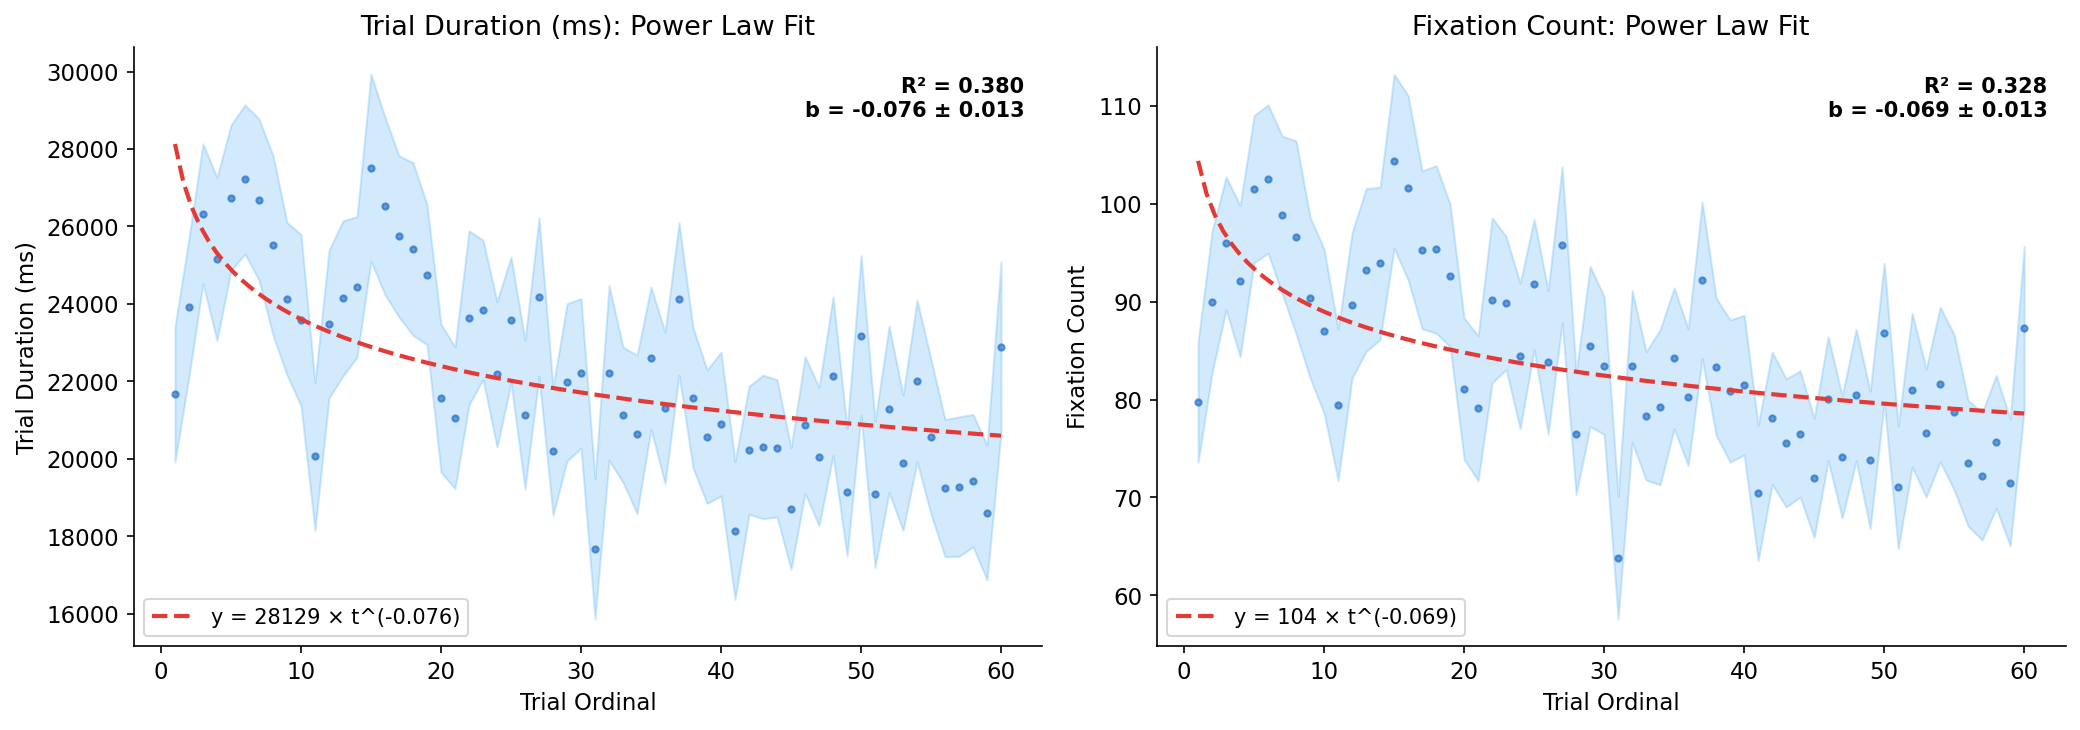

Saved 18_learning_powerlaw.png


In [7]:
# ── Power-law fit: duration and fixations ─────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (metric, label) in zip(axes, [('duration_ms', 'Trial Duration (ms)'),
                                        ('n_fixations', 'Fixation Count')]):
    ords, means, sems = by_ordinal(records, metric)
    
    # Filter valid
    mask = np.isfinite(means) & (means > 0) & (ords > 0)
    x, y = ords[mask], means[mask]
    
    # Power law: y = a * x^b → log(y) = log(a) + b*log(x)
    log_x, log_y = np.log(x), np.log(y)
    slope, intercept, r_val, p_val, std_err = stats.linregress(log_x, log_y)
    
    # Plot data
    ax.fill_between(x, (means - sems)[mask], (means + sems)[mask],
                     alpha=0.2, color='#2196F3')
    ax.plot(x, y, 'o', color='#1565C0', markersize=3, alpha=0.6)
    
    # Plot power-law fit
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = np.exp(intercept) * x_fit ** slope
    ax.plot(x_fit, y_fit, '--', color='#E53935', linewidth=2,
            label=f'y = {np.exp(intercept):.0f} × t^({slope:.3f})')
    
    ax.set_xlabel('Trial Ordinal')
    ax.set_ylabel(label)
    ax.set_title(f'{label}: Power Law Fit')
    ax.legend(fontsize=10)
    
    ax.text(0.98, 0.95, f'R² = {r_val**2:.3f}\nb = {slope:.3f} ± {std_err:.3f}',
            transform=ax.transAxes, fontsize=10, ha='right', va='top',
            fontweight='bold')

plt.tight_layout()
plt.savefig('18_learning_powerlaw.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved 18_learning_powerlaw.png')

## Individual Differences

Spaghetti plot: each participant's trial duration smoothed over a 5-trial window. Some participants may show rapid learning (steep initial drop), others may be flat (already expert or never learning). The spread quantifies how much of the variance is between-participants vs. within-participant learning.

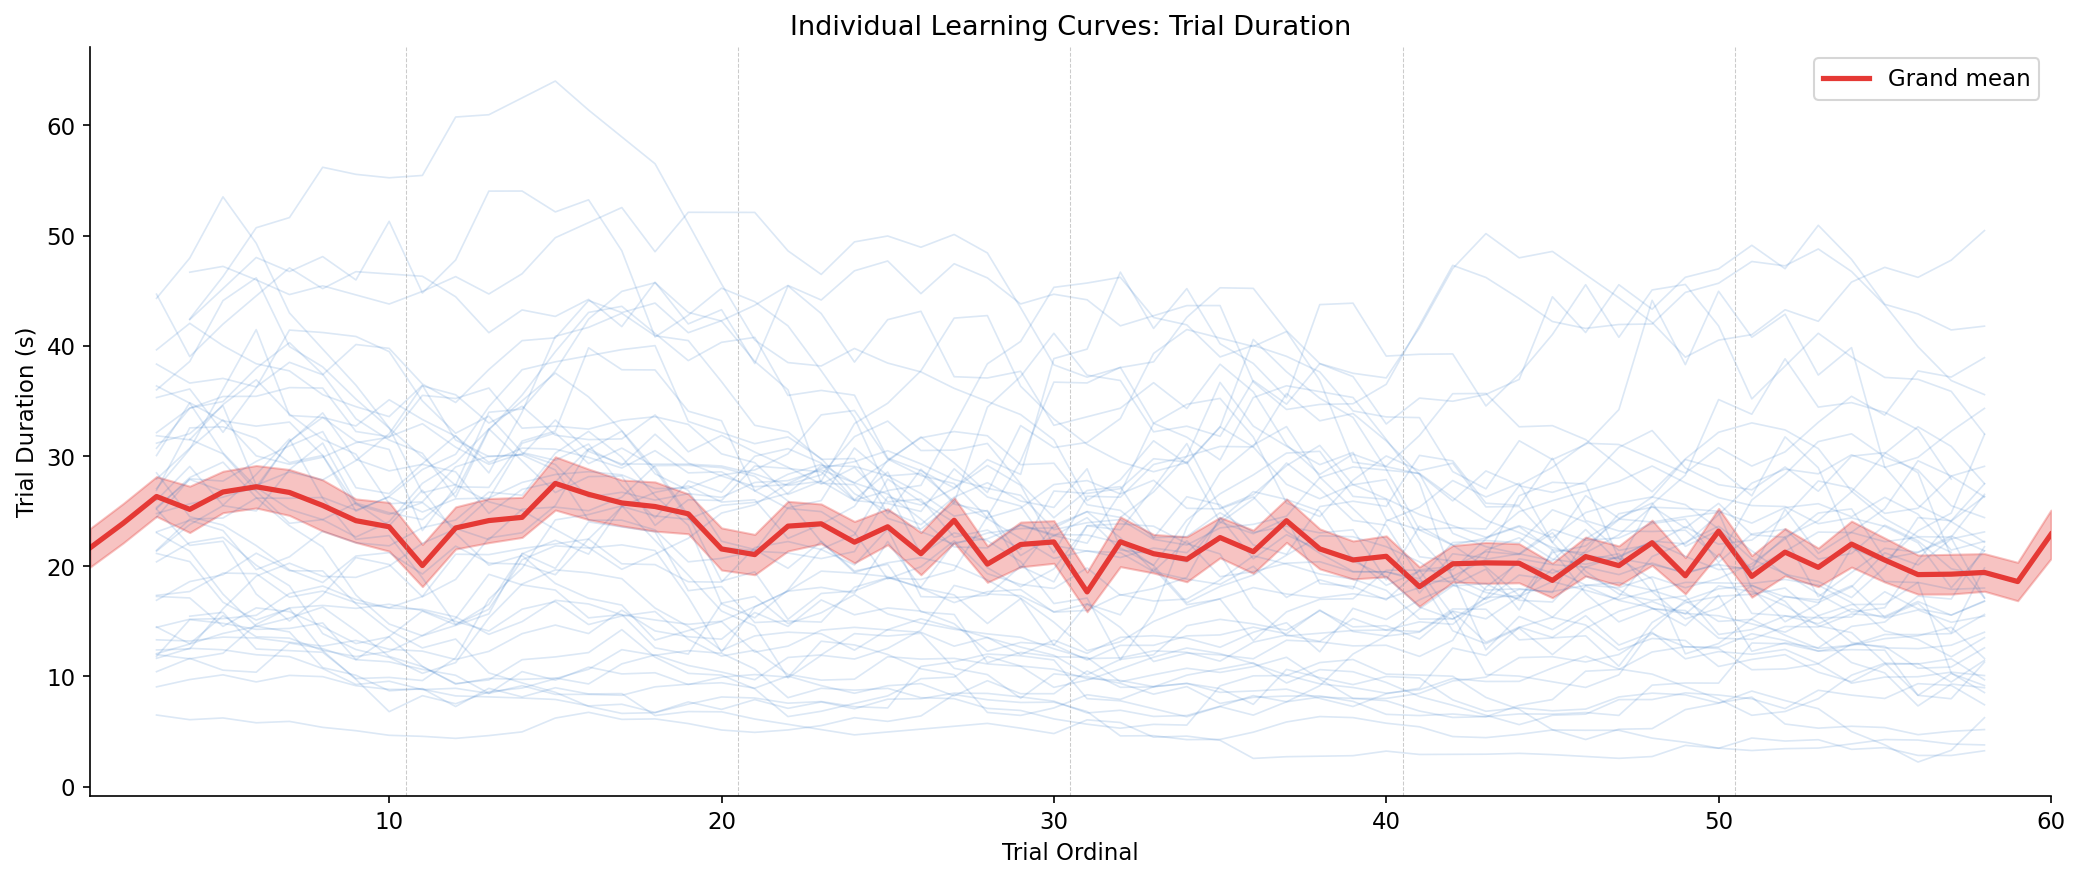


Per-participant ρ(ordinal, duration): n=47
  Mean ρ = -0.214, Median ρ = -0.241
  34 / 47 participants show negative trend (speeding up)
  24 / 47 show ρ < -0.2 (substantial learning)


In [8]:
# ── Individual participant learning curves (duration) ─────────────────

pid_curves = defaultdict(list)  # pid → [(ordinal, duration)]
for r in records:
    if r['duration_ms'] is not None:
        pid_curves[r['pid']].append((r['ordinal'], r['duration_ms']))

fig, ax = plt.subplots(figsize=(14, 6))

# Per-participant smoothed curves
for pid, pts in sorted(pid_curves.items()):
    pts.sort()
    ords = [p[0] for p in pts]
    durs = [p[1] for p in pts]
    
    if len(durs) < 10:
        continue
    
    # 5-trial moving average
    kernel = 5
    smoothed = np.convolve(durs, np.ones(kernel)/kernel, mode='valid')
    smooth_x = ords[kernel//2:kernel//2+len(smoothed)]
    
    ax.plot(smooth_x, smoothed / 1000, alpha=0.15, linewidth=0.8, color='#1565C0')

# Grand mean overlay
ords_g, means_g, sems_g = by_ordinal(records, 'duration_ms')
ax.plot(ords_g, means_g / 1000, color='#E53935', linewidth=2.5, label='Grand mean')
ax.fill_between(ords_g, (means_g - sems_g) / 1000, (means_g + sems_g) / 1000,
                alpha=0.3, color='#E53935')

for b in [10.5, 20.5, 30.5, 40.5, 50.5]:
    ax.axvline(b, color='#999', linewidth=0.5, linestyle='--', alpha=0.5)

ax.set_xlabel('Trial Ordinal')
ax.set_ylabel('Trial Duration (s)')
ax.set_title('Individual Learning Curves: Trial Duration')
ax.legend(fontsize=11)
ax.set_xlim(1, 60)

plt.tight_layout()
plt.savefig('18_learning_individual.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-participant learning rate (Spearman ρ with ordinal)
participant_rhos = {}
for pid, pts in pid_curves.items():
    if len(pts) < 20:
        continue
    ords = [p[0] for p in pts]
    durs = [p[1] for p in pts]
    rho, p = stats.spearmanr(ords, durs)
    participant_rhos[pid] = rho

rhos = list(participant_rhos.values())
print(f'\nPer-participant ρ(ordinal, duration): n={len(rhos)}')
print(f'  Mean ρ = {np.mean(rhos):.3f}, Median ρ = {np.median(rhos):.3f}')
print(f'  {sum(1 for r in rhos if r < 0)} / {len(rhos)} participants show negative trend (speeding up)')
print(f'  {sum(1 for r in rhos if r < -0.2)} / {len(rhos)} show ρ < -0.2 (substantial learning)')